In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import warnings

# 显示中文格式
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings("ignore")


In [52]:
# 参数设置
FS = 4
CUTOFF = 0.1
ORDER = 4
MIN_AMP = 0.05
MIN_INTERVAL_S = 1.0

In [53]:
# 读取数据
df = pd.read_excel("GSR_SCL_SCR_AllEvents.xlsx")
df

,组别,姓名,飞行天数,阶段,data
0,A,付瑞晗,2,hejiu,1.561250e+06
1,A,付瑞晗,2,hejiu,1.561945e+06
2,A,付瑞晗,2,hejiu,1.561511e+06
3,A,付瑞晗,2,hejiu,1.561072e+06
4,A,付瑞晗,2,hejiu,1.561473e+06
...,...,...,...,...,...
405101,B,陈妍,7,jiangluo,9.336832e+05
405102,B,陈妍,7,jiangluo,9.337367e+05
405103,B,陈妍,7,jiangluo,9.339863e+05
405104,B,陈妍,7,jiangluo,9.343174e+05


In [54]:
df.姓名.unique()

array(['付瑞晗', '刘子皓', '张渊博', '徐子焰', '徐文婷', '徐梓军', '曾奇', '朱祖恩', '李嘉文',
       '李国荣', '李天琦', '杨珊珊', '王威', '王榕榕', '达格吉', '黄博文', '冯晓娅', '冯科嘉',
       '刘勇杰', '周鑫颜', '朱娇娇', '杜佳鑫', '毛华灏', '王子铭', '祖丽米热', '祝鹏程', '程腾宇',
       '肖雨晨', '胡浩男', '董嘉乐', '郭浚杰', '陈妍'], dtype=object)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


第2天降落-付瑞晗的GSR信号长度为149
第3天降落-付瑞晗的GSR信号长度为157
第4天降落-付瑞晗的GSR信号长度为389
第5天降落-付瑞晗的GSR信号长度为321
第6天降落-付瑞晗的GSR信号长度为277
第7天降落-付瑞晗的GSR信号长度为337


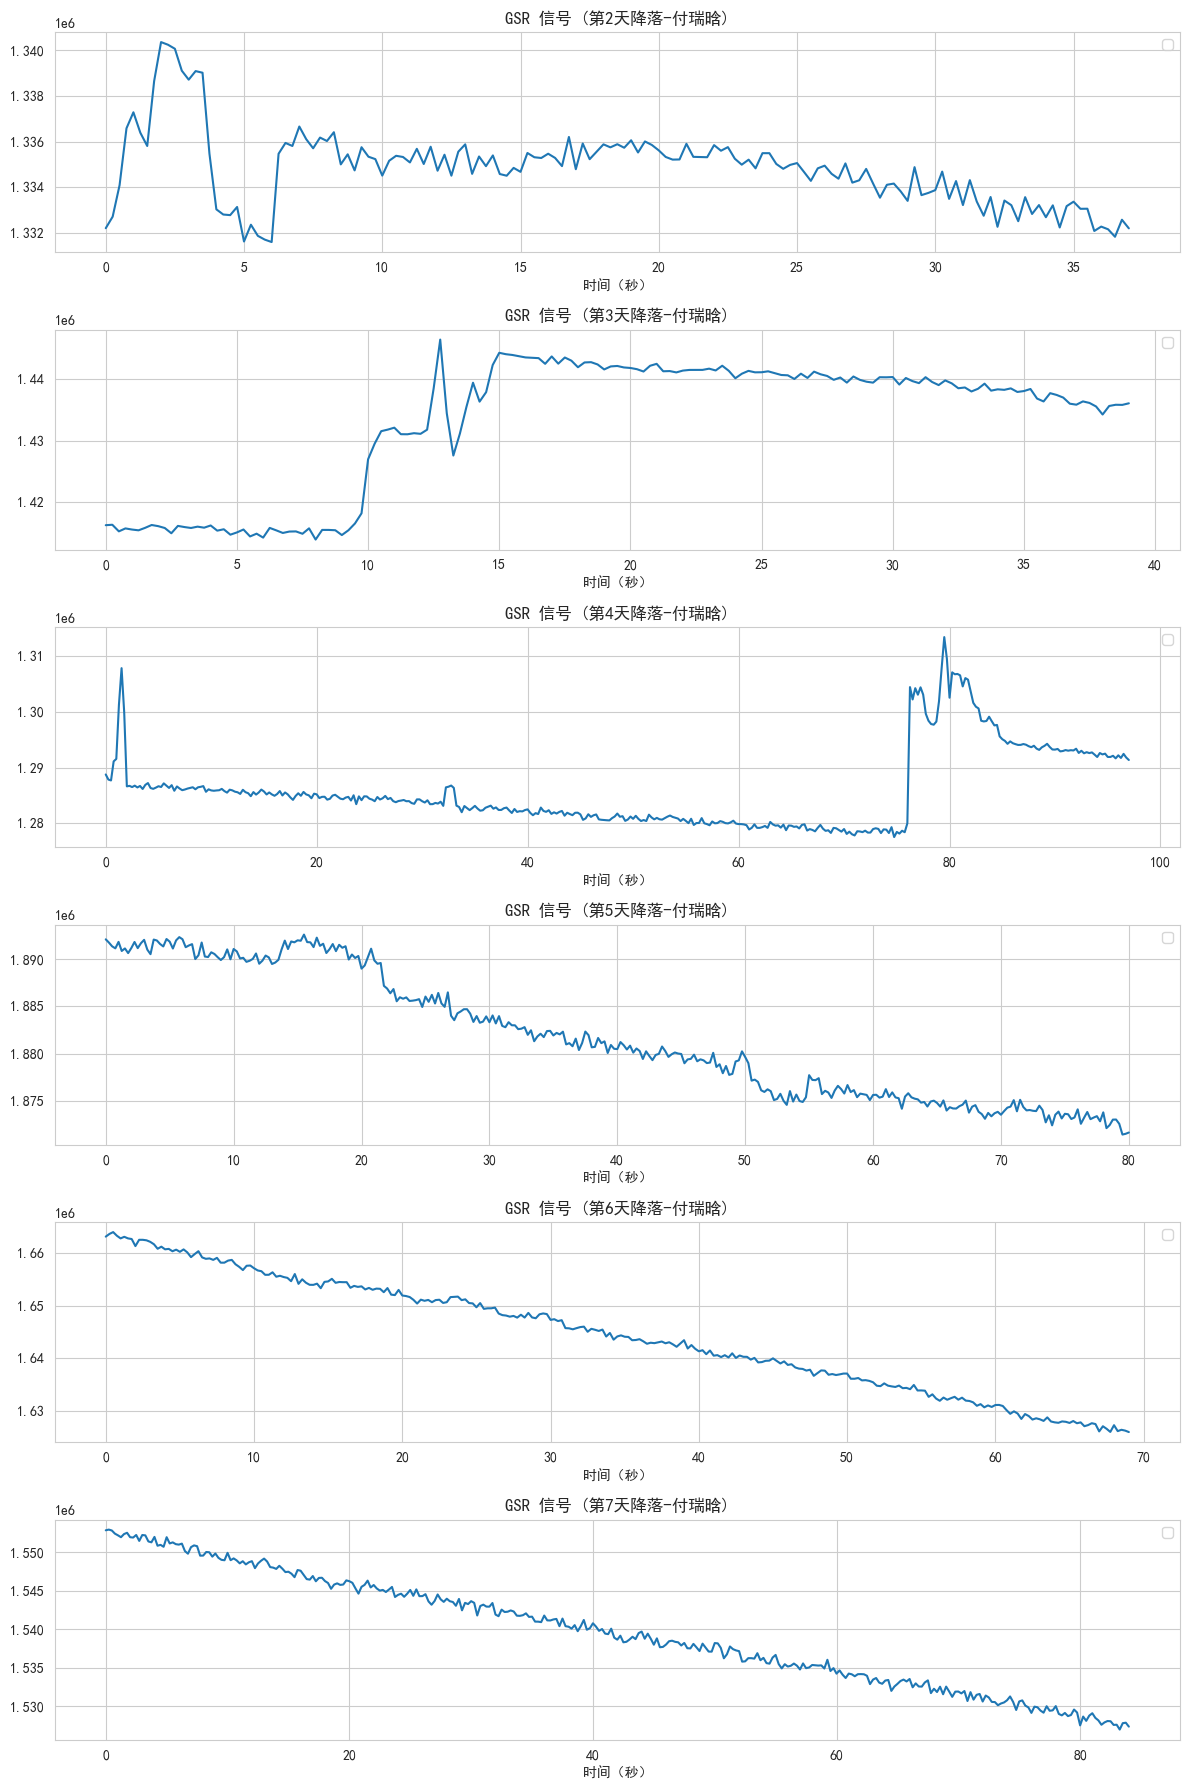

In [55]:
# 挑选被试和阶段，遍历飞行天数2到7
plt.figure(figsize=(12, 18))  # 增大画布高度以容纳6个子图
sampling_rate = 4  # 假设采样频率为4Hz（每秒4个数据点）
name = '付瑞晗'  # 被试姓名
phase = 'jiangluo'  # 阶段
# 遍历飞行天数2到7
for day in range(2, 8):
    # 筛选对应飞行天数的数据
    sub_df = df[(df['姓名'] == name) &
                (df['阶段'] == 'jiangluo') &
                (df['飞行天数'] == day)]

    gsr_signal = sub_df['data'].values.astype(float)

    # 创建子图，6行1列，当前是第day-1个（因为从2开始）
    plt.subplot(6, 1, day - 1)
    # 假设采样频率为4Hz（每秒4个数据点）
    time = np.arange(len(gsr_signal)) / sampling_rate  # 生成时间数组（单位：秒）
    print(f"第{day}天降落-{name}的GSR信号长度为{len(gsr_signal)}")
    plt.plot(time, gsr_signal)  # 明确指定X轴为时间
    plt.xlabel("时间（秒）")  # 添加横轴标签
    plt.title(f"GSR 信号 (第{day}天降落-{name})")
    plt.legend()

plt.tight_layout()  # 自动调整布局，避免标题和标签重叠
plt.show()


In [56]:
sub_df = df[(df['姓名'] == '刘子皓') & (df['阶段'] == '1') & (df['飞行天数'] == 7)]
sub_df

,组别,姓名,飞行天数,阶段,data
24017,A,刘子皓,7,1,1.028904e+06
24018,A,刘子皓,7,1,1.028417e+06
24019,A,刘子皓,7,1,1.028403e+06
24020,A,刘子皓,7,1,1.028125e+06
24021,A,刘子皓,7,1,1.028133e+06
...,...,...,...,...,...
24097,A,刘子皓,7,1,1.016017e+06
24098,A,刘子皓,7,1,1.015461e+06
24099,A,刘子皓,7,1,1.015317e+06
24100,A,刘子皓,7,1,1.015316e+06


In [57]:
# 挑选被试和阶段，遍历飞行天数2到7
sampling_rate = 4  # 假设采样频率为4Hz（每秒4个数据点）
name_list = df['姓名'].unique()  # 所有被试姓名
phase = 'jiangluo'  # 阶段
# 遍历飞行天数2到7
for name in name_list:

    phase = 'jiangluo'  # 阶段
    # 遍历飞行天数2到7
    for day in range(2, 8):
        # 筛选对应飞行天数的数据
        sub_df = df[(df['姓名'] == name) &
                    (df['阶段'] == 'jiangluo') &
                    (df['飞行天数'] == day)]

        gsr_signal = sub_df['data'].values.astype(float)
        # 假设采样频率为4Hz（每秒4个数据点）
        time = np.arange(len(gsr_signal)) / sampling_rate  # 生成时间数组（单位：秒）
        print(f"第{day}天降落-{name}的GSR信号长度为{len(gsr_signal)}")
    print()


第2天降落-付瑞晗的GSR信号长度为149
第3天降落-付瑞晗的GSR信号长度为157
第4天降落-付瑞晗的GSR信号长度为389
第5天降落-付瑞晗的GSR信号长度为321
第6天降落-付瑞晗的GSR信号长度为277
第7天降落-付瑞晗的GSR信号长度为337

第2天降落-刘子皓的GSR信号长度为325
第3天降落-刘子皓的GSR信号长度为393
第4天降落-刘子皓的GSR信号长度为161
第5天降落-刘子皓的GSR信号长度为216
第6天降落-刘子皓的GSR信号长度为281
第7天降落-刘子皓的GSR信号长度为277

第2天降落-张渊博的GSR信号长度为197
第3天降落-张渊博的GSR信号长度为169
第4天降落-张渊博的GSR信号长度为321
第5天降落-张渊博的GSR信号长度为181
第6天降落-张渊博的GSR信号长度为129
第7天降落-张渊博的GSR信号长度为161

第2天降落-徐子焰的GSR信号长度为333
第3天降落-徐子焰的GSR信号长度为301
第4天降落-徐子焰的GSR信号长度为336
第5天降落-徐子焰的GSR信号长度为349
第6天降落-徐子焰的GSR信号长度为441
第7天降落-徐子焰的GSR信号长度为557

第2天降落-徐文婷的GSR信号长度为257
第3天降落-徐文婷的GSR信号长度为285
第4天降落-徐文婷的GSR信号长度为489
第5天降落-徐文婷的GSR信号长度为321
第6天降落-徐文婷的GSR信号长度为153
第7天降落-徐文婷的GSR信号长度为273

第2天降落-徐梓军的GSR信号长度为89
第3天降落-徐梓军的GSR信号长度为221
第4天降落-徐梓军的GSR信号长度为269
第5天降落-徐梓军的GSR信号长度为245
第6天降落-徐梓军的GSR信号长度为272
第7天降落-徐梓军的GSR信号长度为297

第2天降落-曾奇的GSR信号长度为129
第3天降落-曾奇的GSR信号长度为165
第4天降落-曾奇的GSR信号长度为253
第5天降落-曾奇的GSR信号长度为221
第6天降落-曾奇的GSR信号长度为161
第7天降落-曾奇的GSR信号长度为257

第2天降落-朱祖恩的GSR信号长度为113
第3天降落-朱祖恩的GSR信号长度为141
第4天降落-朱祖恩的GSR信号长度为213
第5天降落-朱祖恩的

In [58]:
# 查看缺失值
print('缺失值个数：', df.isnull().sum().sum())
# 查看异常值
df1 = df[df['data'].isnull()]
df1

缺失值个数： 0


,组别,姓名,飞行天数,阶段,data
